## Hyperparameters setting

In [ ]:
run_name = "final_model"

param_dic = {
    "embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "n_neighbors": 15,                  # 15     --> 15
    "n_components": 10,                 # 5      --> 10
    "min_dist": 0.0,                    # 0.1    --> 0.0
    "random_state": [0, 1, 15, 11, 37],
    #"random_state": [15],
    "min_cluster_size": 20,             # 10     --> 20
    "min_df": 3,                        # 0      --> 3
    "max_df": 1.0,                      # 1.0    --> 1.0
    "ngram_range": (1, 3),              # (1, 2) --> (1, 3)
    "top_n_words": 5                    # 10     --> 5
}

## Model run preparation

Import data

In [24]:
import os
import pandas as pd

df = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_advice_fulltext.csv"))
docs = list(df["text"])
classes = list(df["gen"])
id = list(df["ID"])

docs[:5]

['Consider each round carefully as it appears the same colours always go up against each other.\xa0 So yellow will always play against orange and purple against green.\xa0 Choose each colour in each round and remember who is best.\xa0 This will maximise your number of points.\xa0 Good luck.\xa0\xa0',
 'If the multiplier is 5, then choose the pointy hat (if they have different hats)If the multiplier is 1, then choose the round hat (if they have different hats)If they have the same hats and you have a choice of pink and brown, choose brown.\xa0If they have the same hats and you have a choice of yellow and red, you need to work out what colour the baske will be and choose that colour. That will alternate between red and yellow each go, so try and take notegood luck!',
 'The game is fantastic but requires you to think quickly and react.The features and characters is easy to use and move as well as the keys to play ths game is easy to each without hurting the fingers or hand.A lovely game. 

Pre-load embeddings

In [25]:
from sentence_transformers import SentenceTransformer

# Pre-calculate embeddings
embedding_model = SentenceTransformer(param_dic["embedding_model"], use_auth_token=False)
embeddings = embedding_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Prepare topic fine-tuning models

In [26]:
from bertopic.representation import KeyBERTInspired
from bertopic.representation import MaximalMarginalRelevance

# The main representation of a topic
main_representation = KeyBERTInspired()

# Additional ways of representing a topic
aspect_model2 = [KeyBERTInspired(top_n_words=20), MaximalMarginalRelevance(diversity=.5)]

# Add all models together to be run in a single `fit`
representation_model = {
   "KeyBERT": main_representation,
   "MMR":  aspect_model2 
}

## Model run

Train model

In [27]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from evaluation import evaluate_model

# Data saving

data = []

# Setup different models

cluster_model = HDBSCAN(min_cluster_size=param_dic["min_cluster_size"], metric='euclidean', cluster_selection_method='eom', prediction_data=True)
vectorizer_model = CountVectorizer(stop_words="english", min_df=param_dic["min_df"], max_df=param_dic["max_df"], ngram_range=param_dic["ngram_range"])
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

for seed in param_dic["random_state"]:

    umap_model = UMAP(n_neighbors=param_dic["n_neighbors"], n_components=param_dic["n_components"], min_dist=param_dic["min_dist"], metric='cosine', random_state=seed)

    topic_model = BERTopic(

        # Pipeline models
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,

        # Hyperparameters
        top_n_words=param_dic["top_n_words"],
        n_gram_range=param_dic["ngram_range"],
        min_topic_size="auto", #use HDBSCAN
        verbose=True,

        # General parameters
        calculate_probabilities=True,
        language="english"
    )

    topics, probs = topic_model.fit_transform(docs, embeddings)

    eval_res = evaluate_model(topic_model, docs, topics, embeddings, topk=param_dic["top_n_words"])
    data.append([seed, max(topic_model.topics_)] + [i for i in eval_res])

data = pd.DataFrame(data, columns=["seed", "nr_topic", "c_v", "c_npmi", "t_D", "silhouette", "similarity"])
data

2025-02-19 16:49:03,539 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-19 16:49:05,923 - BERTopic - Dimensionality - Completed ✓
2025-02-19 16:49:05,923 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-19 16:49:05,967 - BERTopic - Cluster - Completed ✓
2025-02-19 16:49:05,971 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-19 16:49:09,603 - BERTopic - Representation - Completed ✓
100%|██████████| 1/1 [00:00<00:00,  1.60it/s]
2025-02-19 16:49:39,762 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-02-19 16:49:42,134 - BERTopic - Dimensionality - Completed ✓
2025-02-19 16:49:42,135 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-02-19 16:49:42,178 - BERTopic - Cluster - Completed ✓
2025-02-19 16:49:42,179 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-02-19 16:49:46,004 - BERTop

,seed,nr_topic,c_v,c_npmi,t_D,silhouette,similarity
0,0,8,0.900802,0.274067,0.644444,0.525353,0.573779
1,1,7,0.903157,0.284620,0.675000,0.477466,0.561413
2,15,9,0.868834,0.238068,0.580000,0.528965,0.597152
3,11,7,0.903525,0.281856,0.675000,0.478767,0.561378
4,37,8,0.903658,0.266621,0.533333,0.547069,0.604212


In [28]:
a = topic_model.get_document_info(docs)

In [29]:
for topic in topic_model.get_topics():
    topic_terms = topic_model.get_topic(topic)
    print(f"Topic {topic}:")
    for term, score in topic_terms:
        doc_freq = sum(1 for doc in docs if term in doc)
        print(f"  {term}: appears in {doc_freq} documents")

Topic -1:
  mushrooms: appears in 452 documents
  gnome: appears in 659 documents
  gnomes: appears in 493 documents
  multiplier: appears in 93 documents
  yellow: appears in 351 documents
Topic 0:
  gnome: appears in 659 documents
  points: appears in 256 documents
  gnomes: appears in 493 documents
  colour: appears in 485 documents
  hat: appears in 605 documents
Topic 1:
  basket: appears in 269 documents
  red: appears in 410 documents
  yellow: appears in 351 documents
  mushrooms: appears in 452 documents
  gnomes: appears in 493 documents
Topic 2:
  points: appears in 256 documents
  blue: appears in 295 documents
  colours: appears in 256 documents
  pink: appears in 242 documents
  purple: appears in 269 documents
Topic 3:
  mushrooms: appears in 452 documents
  gnome: appears in 659 documents
  gnomes: appears in 493 documents
  colour: appears in 485 documents
  try: appears in 191 documents
Topic 4:
  basket: appears in 269 documents
  red: appears in 410 documents
  bask

## Model visualization

In [30]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,MMR,Representative_Docs
0,-1,173,-1_mushrooms_gnome_gnomes_multiplier,"[mushrooms, gnome, gnomes, multiplier, yellow]","[colour gnome, gnomes, gnome, number mushrooms...","[colour gnome, gnomes, number mushrooms, gnome...","[Remember these colours: Green, yellow, orange..."
1,0,256,0_gnome_points_gnomes_colour,"[gnome, points, gnomes, colour, hat]","[colour gnomes, colour gnome, gnomes, gnome, c...","[colour gnomes, gnome, colours, points, yellow...",[It appears that gnomes of certain colours wil...
2,1,140,1_basket_red_yellow_mushrooms,"[basket, red, yellow, mushrooms, gnomes]","[gnomes yellow basket, gnomes red basket, bask...","[gnomes yellow basket, gnomes red basket, bask...",[There are two different colours of baskets in...
3,2,108,2_points_blue_colours_pink,"[points, blue, colours, pink, purple]","[certain colours, pick colour, colours, colors...","[certain colours, pick colour, colours, colors...","[There are two themes of colours, purple, pink..."
4,3,103,3_mushrooms_gnome_gnomes_colour,"[mushrooms, gnome, gnomes, colour, try]","[gnomes mushrooms, colour gnome, number mushro...","[gnomes mushrooms, colour gnome, number mushro...",[It might be difficult choosing the gnome that...
5,4,80,4_basket_red_baskets_yellow,"[basket, red, baskets, yellow, points]","[gnomes baskets, basket colours, colour basket...","[gnomes baskets, basket colours, baskets red y...",[On the screen you will be presented with two ...
6,5,60,5_mushrooms_colours_mushroom_change,"[mushrooms, colours, mushroom, change, color]","[colour gives mushrooms, colours mushrooms, mu...","[colour gives mushrooms, colours mushrooms, mu...",[Pay attention to the colours as certain colo...
7,6,33,6_hats_hat_tall_short,"[hats, hat, tall, short, taller]","[short hats, tall hats, short hat, taller hat,...","[short hats, smaller hat, hat colour, hat bett...","[Do your best, seems pretty random and difficu..."
8,7,24,7_forest_mushrooms_green_gnomes,"[forest, mushrooms, green, gnomes, blue]","[mushrooms gnomes, mushrooms forest, number mu...","[mushrooms gnomes, mushrooms forest, number mu...","[green, yellow, orange, and blue gnomes take y..."
9,8,23,8_hat_mushrooms_tall_hats,"[hat, mushrooms, tall, hats, gnome]","[gnome mushrooms, gnomes earn mushrooms, hats ...","[gnome mushrooms, gnomes earn mushrooms, hat g...",[I scored more highly when I went right for 5+...


In [31]:
topic_model.visualize_documents(docs)

In [32]:
topic_model.visualize_hierarchy()

Dynamic topic-modeling

In [33]:
topics_over_time = topic_model.topics_over_time(docs, classes)

topic_model.visualize_topics_over_time(topics_over_time)

10it [00:00, 43.91it/s]


## STATS

In [34]:
topic_distr, _ = topic_model.approximate_distribution(docs)
df_stat = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()), "data", "data_stake.csv"))

for topic_n in range(len(topic_distr[0,:])):
    topic_name = "topic_" + str(topic_n)
    df_stat[topic_name] = topic_distr[:, topic_n]

df_stat["assigned_topic"] = topic_model.topics_

100%|██████████| 1/1 [00:00<00:00,  2.51it/s]


In [35]:
parent_topic_weight = []
var_names = [f'topic_{n}' for n in range(len(topic_distr[0, :]))]

for i in range(len(df_stat["ID"])):
    parent_ID = df_stat["parent_ID"][i]
    parent_row = df_stat[df_stat["ID"] == parent_ID]
    if len(parent_row) < 1:
        parent_topic_weight.append([None for n in range(len(topic_distr[0, :]))])
    else:
        res = parent_row[var_names].values.tolist()
        parent_topic_weight.append(res[0])

parent_topic_df = pd.DataFrame(parent_topic_weight)
parent_topic_df.columns = [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

df_stat = pd.concat([df_stat, parent_topic_df], axis=1)
df_stat.tail(2)

,Unnamed: 0,ID,understanding_score,pl1_understanding,pl2_understanding,score_corrected,rank,filename,binary_score,ADVICE,...,assigned_topic,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
998,999,668d5331aa58b7e75ff160d7,0.091113,0.161720,0.020506,0.714286,63,234906_experiment_2024-07-10_19h00.46.327.csv,0.609375,"The taller gnomes perform better, yellow is th...",...,0,0.220824,0.191203,0.227651,0.108985,0.130598,0.000000,0.120739,0.000000,0.000000
999,1000,668d822d705c807ed4664ae1,0.820187,0.642993,0.997381,2.688492,5,564113_experiment_2024-07-10_18h59.42.430.csv,0.730469,There are two types of baskets RED or YELLOWRe...,...,1,0.033247,0.308388,0.060755,0.111975,0.254907,0.083248,0.014062,0.089579,0.043839


In [36]:
var_names = ["score_corrected", "pl2_understanding", "pl1_understanding"] + [f'topic_{n}' for n in range(len(topic_distr[0, :]))] + [f'parent_topic_{n}' for n in range(len(topic_distr[0, :]))]

cor_table = df_stat[var_names].corr()
cor_table

,score_corrected,pl2_understanding,pl1_understanding,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,...,topic_8,parent_topic_0,parent_topic_1,parent_topic_2,parent_topic_3,parent_topic_4,parent_topic_5,parent_topic_6,parent_topic_7,parent_topic_8
score_corrected,1.000000,0.455890,0.164747,-0.204244,0.347616,-0.076921,-0.124306,0.331034,-0.078185,-0.141851,...,-0.236698,-0.147182,0.302213,-0.096447,-0.131125,0.273342,-0.116725,-0.136808,0.177811,-0.162930
pl2_understanding,0.455890,1.000000,0.042760,-0.298802,0.599424,-0.214089,-0.215904,0.545348,-0.187564,-0.184488,...,-0.216851,-0.298548,0.549746,-0.181693,-0.203768,0.492982,-0.175787,-0.184601,0.146527,-0.245599
pl1_understanding,0.164747,0.042760,1.000000,-0.001650,0.062682,-0.000458,0.048309,0.033414,-0.013827,-0.076610,...,-0.089472,0.075910,-0.071868,0.025180,0.065924,-0.023638,0.055073,-0.032302,-0.030495,-0.040777
topic_0,-0.204244,-0.298802,-0.001650,1.000000,-0.364961,0.032617,0.022761,-0.141664,-0.311205,-0.003031,...,0.153035,0.296853,-0.255973,0.085514,0.060213,-0.190855,-0.013173,0.063962,-0.104443,0.120194
topic_1,0.347616,0.599424,0.062682,-0.364961,1.000000,-0.258600,-0.294932,0.777246,-0.350331,-0.308518,...,-0.314933,-0.262442,0.638513,-0.134156,-0.249069,0.569705,-0.243889,-0.210042,0.053319,-0.298211
topic_2,-0.076921,-0.214089,-0.000458,0.032617,-0.258600,1.000000,-0.340679,-0.136001,-0.002526,-0.012334,...,-0.384388,0.041796,-0.149053,0.312003,-0.050481,-0.142396,0.058408,-0.057547,-0.057204,-0.108182
topic_3,-0.124306,-0.215904,0.048309,0.022761,-0.294932,-0.340679,1.000000,-0.409107,0.392506,-0.270576,...,0.087221,0.116420,-0.224735,-0.108434,0.322255,-0.217541,0.202160,-0.102557,-0.029271,0.109156
topic_4,0.331034,0.545348,0.033414,-0.141664,0.777246,-0.136001,-0.409107,1.000000,-0.418905,-0.298070,...,-0.398129,-0.199037,0.576144,-0.123693,-0.238875,0.574586,-0.210150,-0.212421,-0.010501,-0.302747
topic_5,-0.078185,-0.187564,-0.013827,-0.311205,-0.350331,-0.002526,0.392506,-0.418905,1.000000,-0.188149,...,-0.101731,-0.045983,-0.199076,0.048009,0.175638,-0.195775,0.340349,-0.128478,-0.020557,0.010331
topic_6,-0.141851,-0.184488,-0.076610,-0.003031,-0.308518,-0.012334,-0.270576,-0.298070,-0.188149,1.000000,...,0.445959,0.065107,-0.206504,-0.020784,-0.077413,-0.202101,-0.090959,0.514502,-0.147288,0.317469


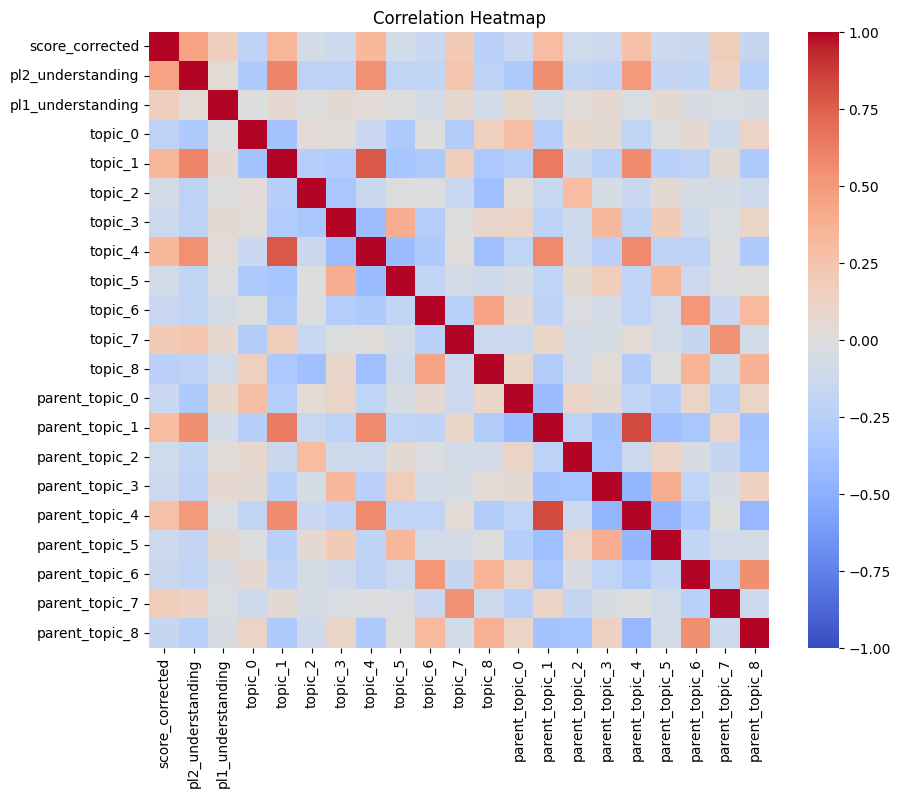

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_table, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

## SAVE DATA

In [38]:
embedding_model = "all-MiniLM-L6-v2"
topic_model.save(os.path.join(os.path.dirname(os.getcwd()), "results", "BERT_fine_tuning", run_name), serialization="safetensors", save_ctfidf=True, save_embedding_model=embedding_model)

In [39]:
data_run = [[run_name, param_dic, data["nr_topic"].mean(), data["c_v"].mean(), data["c_npmi"].mean(), data["t_D"].mean(), data["silhouette"].mean(), data["similarity"].mean()]]

df_run = pd.DataFrame(data_run, columns=["run_name", "params", "nr_topic", "c_v", "c_npmi", "diversity", "silhouette", "similarity"])

df_run.to_csv(os.path.join(os.path.dirname(os.getcwd()), "results", "BERT_fine_tuning", "results.csv"), mode="a", header=False, index=False)

## PLOT

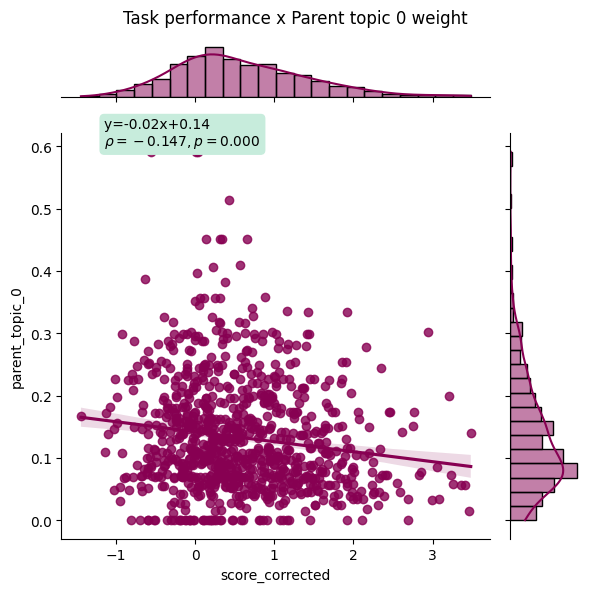

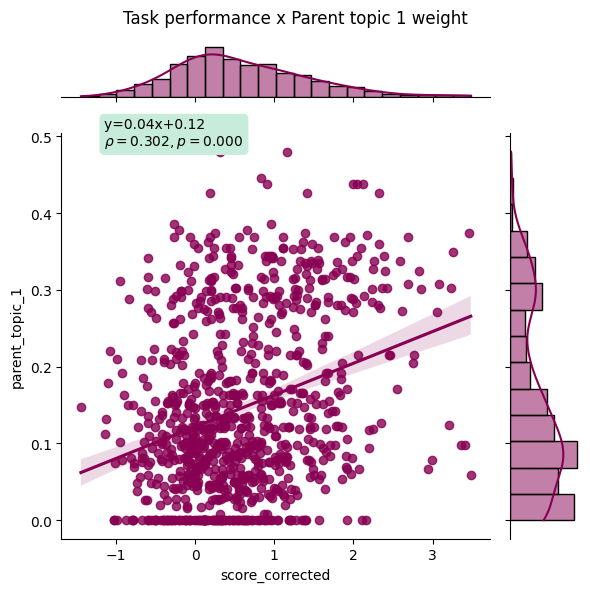

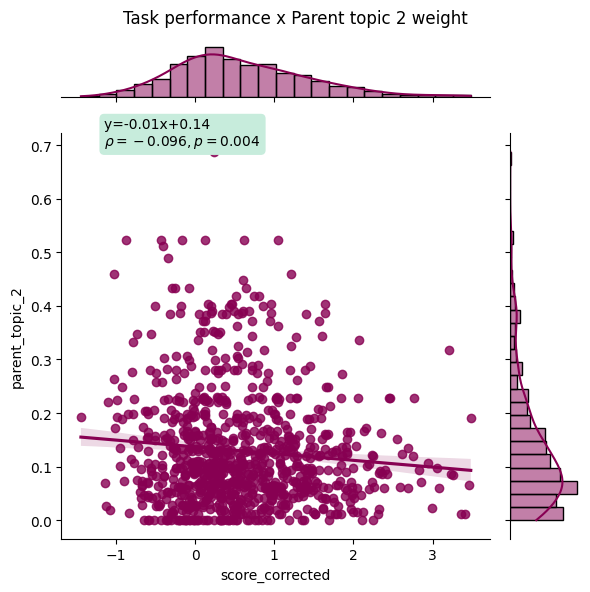

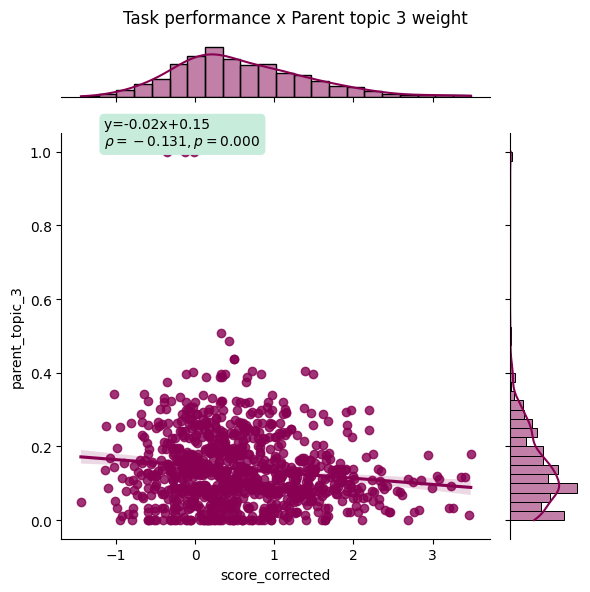

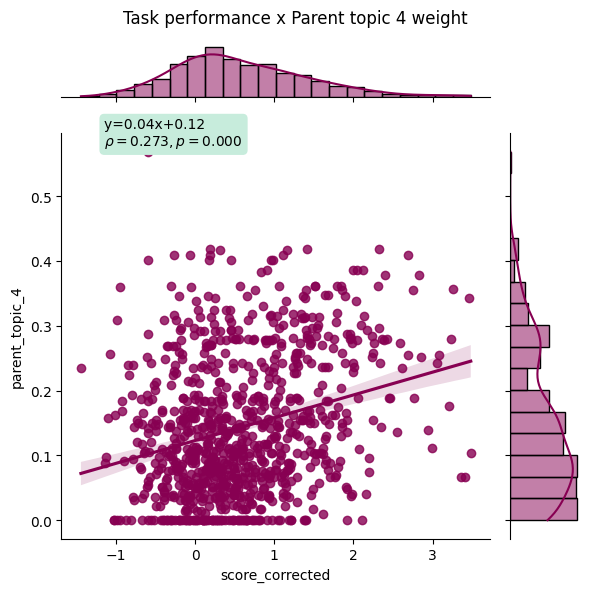

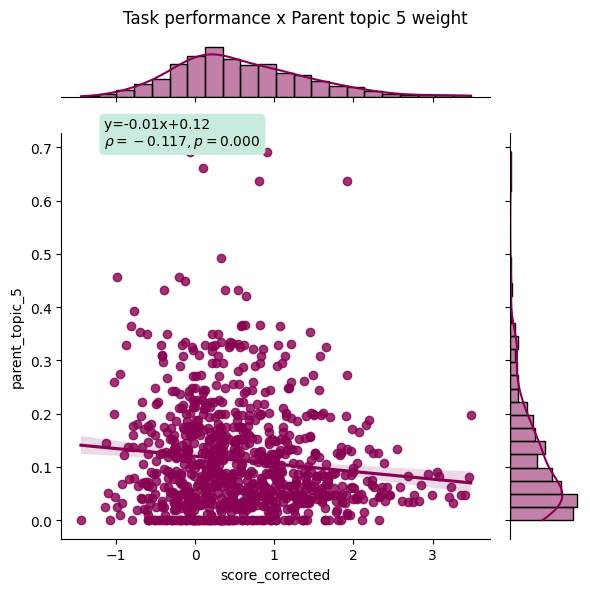

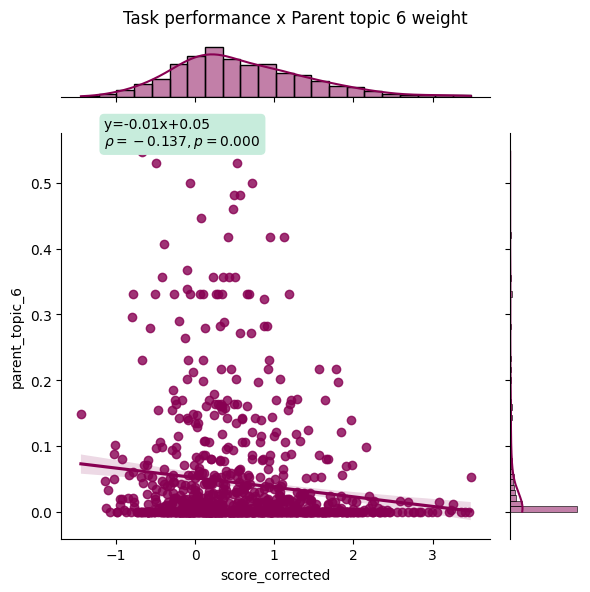

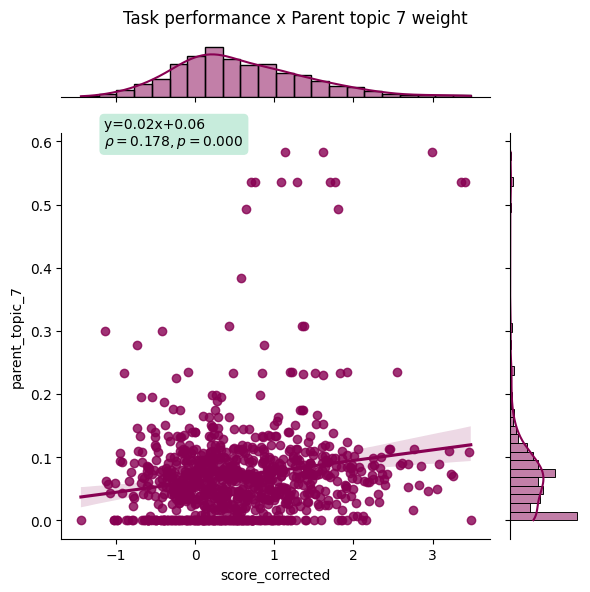

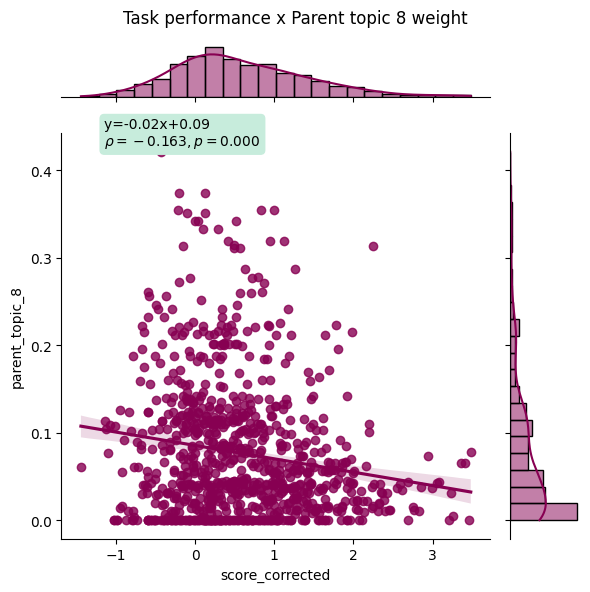

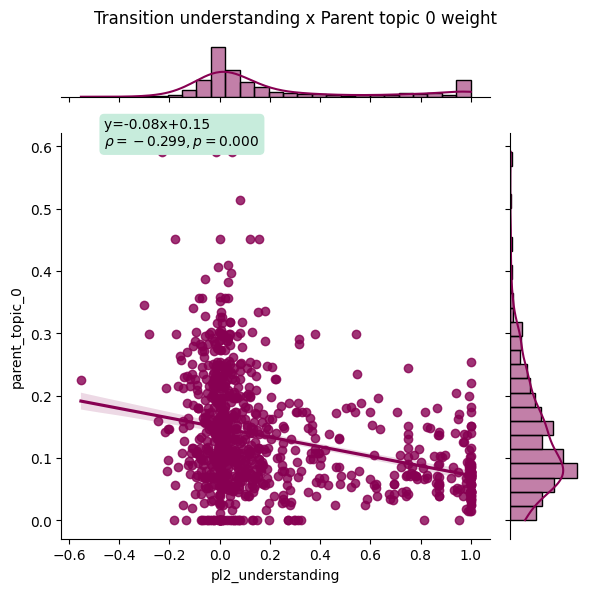

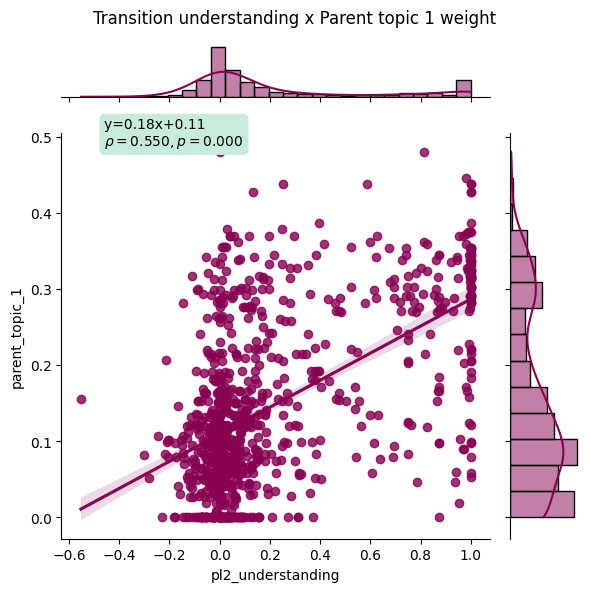

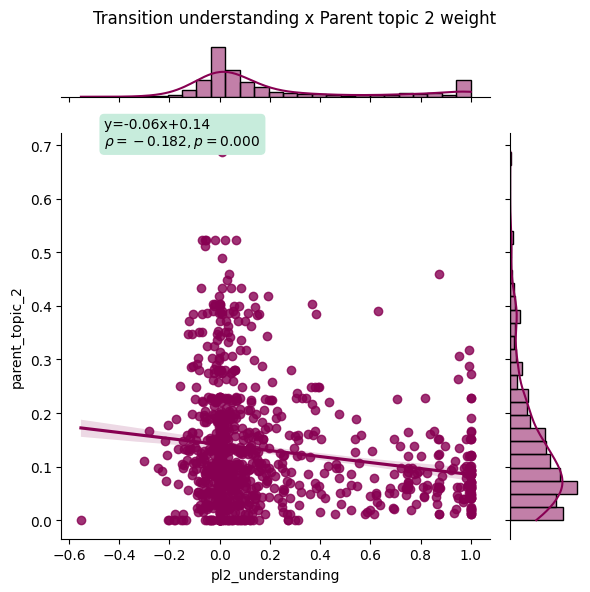

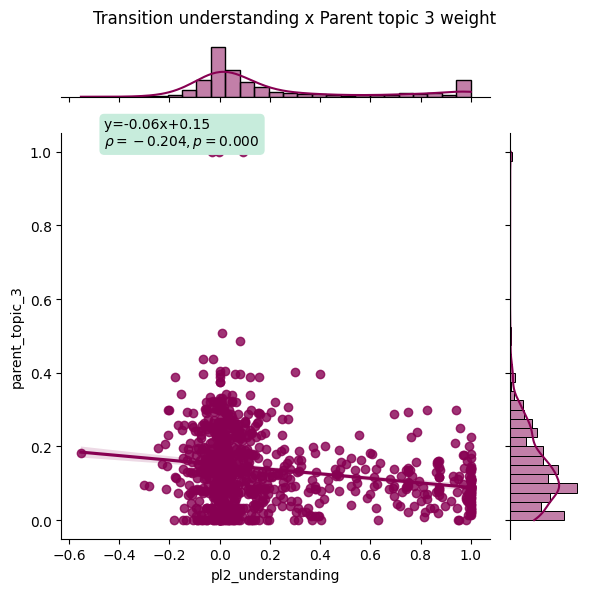

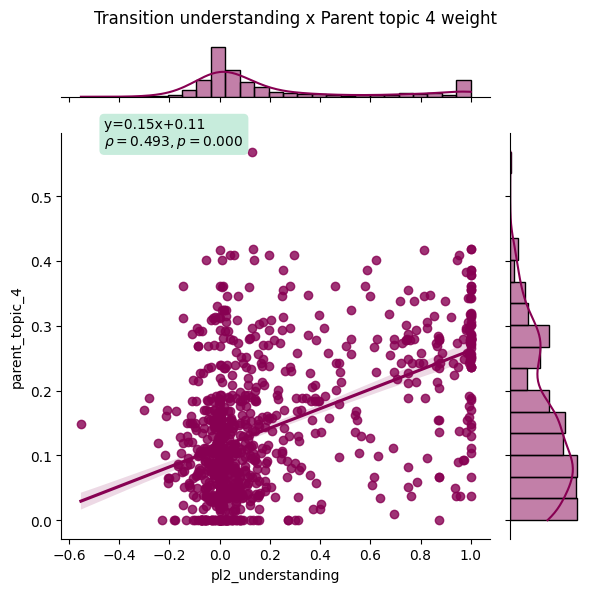

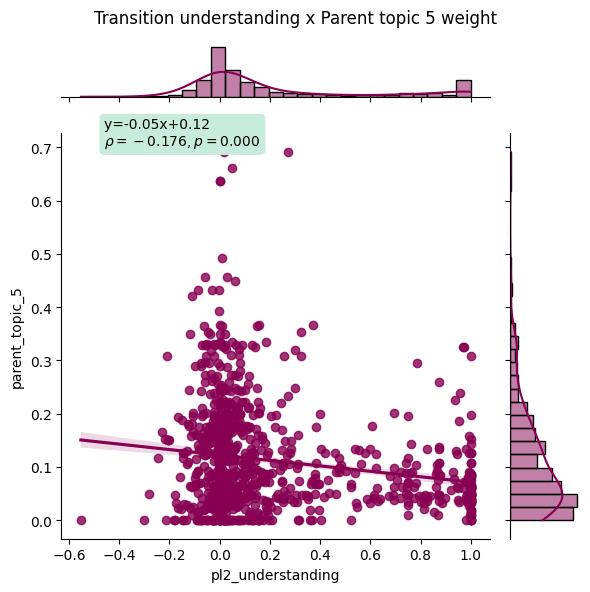

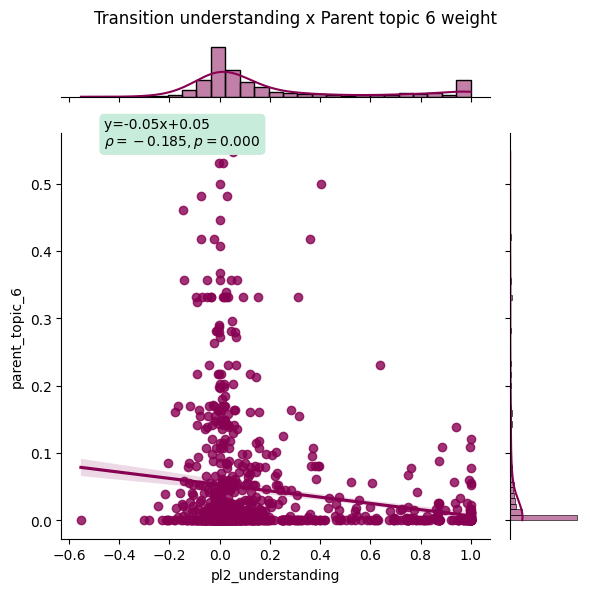

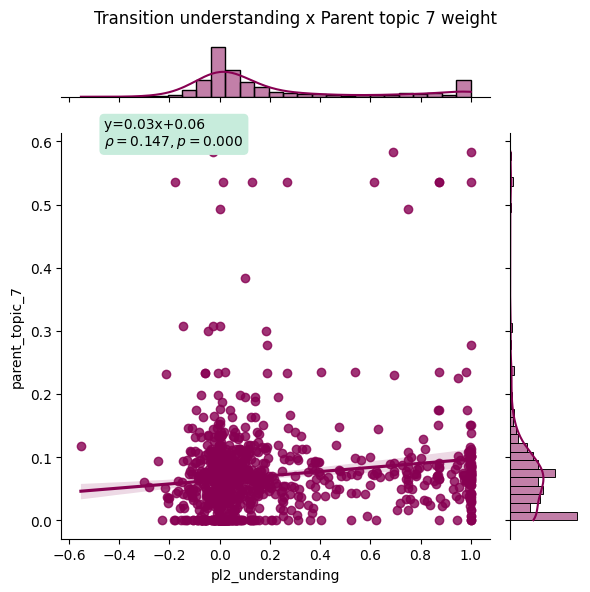

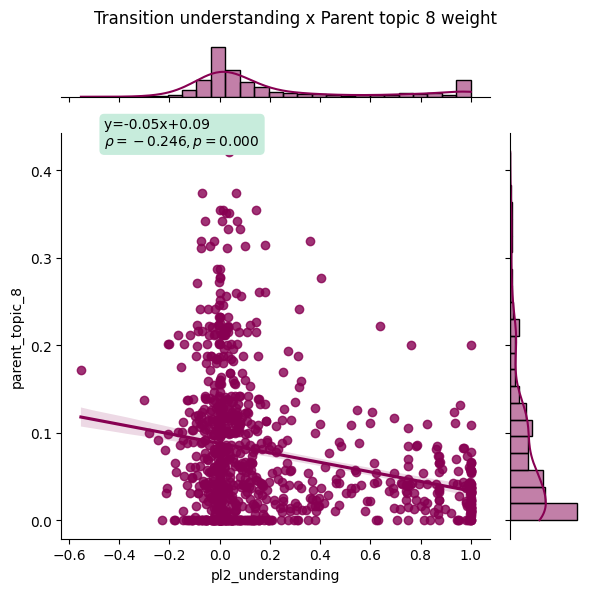

In [40]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def joint_plot(x, y, data, title):
    g = sns.jointplot(x=x, y=y, data=data, kind='reg', color='#870052')
    slope, intercept, r_value, pv, se = stats.linregress(x=data[x], y=data[y])
    g.ax_joint.annotate(f'y={slope:.2f}x+{intercept:.2f} \n$\\rho = {r_value:.3f}, p = {pv:.3f}$',
                        xy=(0.1, 1), xycoords='axes fraction',
                        ha='left', va='center',
                        bbox={'boxstyle': 'round', 'fc': '#C7ECDC', 'ec': '#C7ECDC'})
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

for topic_n in range(len(topic_distr[0, :])):
    joint_plot('score_corrected',
               f'parent_topic_{topic_n}',
               df_stat.query("gen > 1"),
               f'Task performance x Parent topic {topic_n} weight')
for topic_n in range(len(topic_distr[0, :])):
    joint_plot('pl2_understanding',
               f'parent_topic_{topic_n}',
               df_stat.query("gen > 1"),
               f'Transition understanding x Parent topic {topic_n} weight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Custom statistical test, P_val:0.000e+00
0 vs. 1: Custom statistical test, P_val:0.000e+00
6 vs. 7: Custom statistical test, P_val:1.800e-03
7 vs. 8: Custom statistical test, P_val:1.200e-03
-1 vs. 1: Custom statistical test, P_val:0.000e+00
5 vs. 7: Custom statistical test, P_val:3.150e-02
1 vs. 3: Custom statistical test, P_val:0.000e+00
4 vs. 6: Custom statistical test, P_val:1.470e-02
0 vs. 4: Custom statistical test, P_val:1.000e-04
1 vs. 5: Custom statistical test, P_val:2.000e-04
3 vs. 7: Custom statistical test, P_val:2.390e-02
4 vs. 8: Custom statistical test, P_val:1.130e-02
2 vs. 7: Custom statistical test, P_val:1.710e-02
1 vs. 6: Custom statistical test, P_val:0.000e+00
0 vs. 7: Custom statistical test, P_val:2.000e-04
1 vs. 8: Custom statistical test, P_val:0.000e+00
-1 vs. 

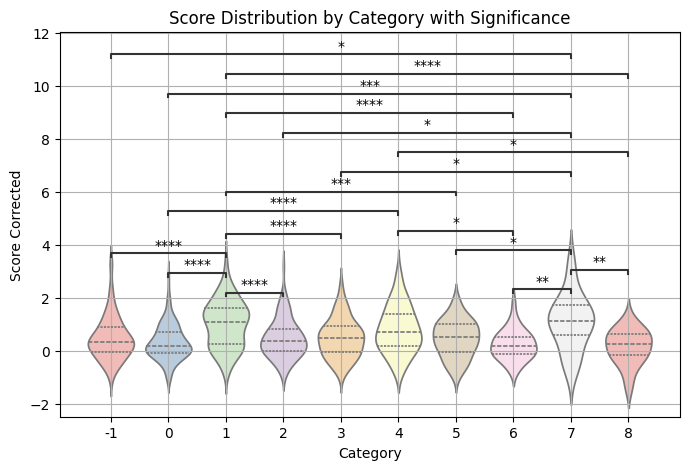

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create the violin plot
plt.figure(figsize=(8, 5))
ax = sns.violinplot(x='assigned_topic', y='score_corrected', data=df_stat, palette="Pastel1", inner="quartile")

# Define category pairs for significance testing
category_pairs = [(cat1, cat2) for i, cat1 in enumerate(df_stat['assigned_topic'].unique()) 
                                for cat2 in df_stat['assigned_topic'].unique()[i+1:]]

# Compute p-values for each pair using Tukey's HSD
p_values = []
tukey = pairwise_tukeyhsd(df_stat['score_corrected'], df_stat["assigned_topic"])

# Convert Tukey results to a DataFrame
tukey_results = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])

# Find the p-value for each category pair
for cat1, cat2 in category_pairs:
    p_value = tukey_results[
        ((tukey_results["group1"] == cat1) & (tukey_results["group2"] == cat2)) |
        ((tukey_results["group1"] == cat2) & (tukey_results["group2"] == cat1))
    ]["p-adj"].values[0]  # Extract p-value
    p_values.append(p_value)



# Add annotations to the plot
annotator = Annotator(ax, category_pairs, data=df_stat, x="assigned_topic", y="score_corrected")
annotator.configure(test=None, text_format="star", loc="inside", hide_non_significant=True)
annotator.set_pvalues(p_values)
annotator.annotate()

# Labels and title
plt.xlabel("Category")
plt.ylabel("Score Corrected")
plt.title("Score Distribution by Category with Significance")
plt.grid(True)
plt.show()


## TEST

In [42]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

topic_distr, _ = topic_model.approximate_distribution(docs)
global_similarity = []

a = topic_model.get_document_info(docs)

for topic_n in range(len(topic_distr[0,:])):
    topic_docs = a[a["Topic"] == topic_n]
    topic_docs = topic_docs[topic_docs["Probability"] == 1]
    embeddings = topic_model._extract_embeddings(list(topic_docs["Document"]))
    similarity_matrix = cosine_similarity(embeddings)
    average_similarity = np.mean(similarity_matrix)
    print(average_similarity)



100%|██████████| 1/1 [00:00<00:00,  2.97it/s]


0.37962037
0.87322646
0.53450036
0.74289155
0.7138136
0.7037002
0.5736734
0.7003357
0.69911313


It appears that gnomes of certain colours will get you more points. Where one colour gnome appears to consistently get more points at 1x (usually more than 5 points) you will want to keep picking that colour. As gnomes appear consistently in the same colour pairs you should compare green to blue, pink to brown, orange to purple and yellow to red. You might want to test out the other colour you're not so keen on when it's 1x points rather than 5x points. It's worth noting that you have to make quick decisions and while you want to select well, don't be so slow as to miss picking a gnome of collection mushrooms at all - don't forget to press the buttons! Make good use of the breaks to stretch and move position so your fingers don't get tired.
It seems as though different colour gnomes give you different numbers of points. They appear in the same colour pairs each time - pink and brown, orange and purple, green and blue and yellow and red. You can test which ones give more points - the be

<Axes: >

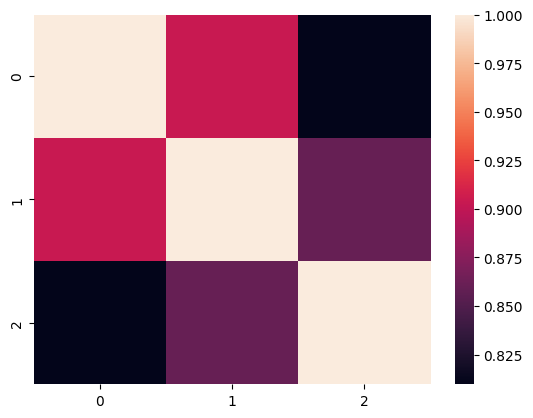

In [43]:
for i in topic_model.get_representative_docs(0):
    print(i)
    
embeddings = topic_model._extract_embeddings(topic_model.get_representative_docs(3))
similarity_matrix = cosine_similarity(embeddings)

import seaborn as sns

sns.heatmap(similarity_matrix)

<Axes: >

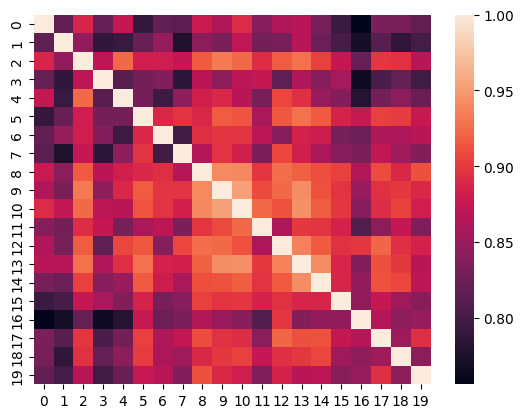

In [44]:
topic_docs = a[a["Topic"] == 1]
topic_docs = topic_docs[topic_docs["Probability"] == 1]

    
embeddings = topic_model._extract_embeddings(list(topic_docs["Document"]))
similarity_matrix = cosine_similarity(embeddings)

import seaborn as sns

sns.heatmap(similarity_matrix)